# BEoRN post-processing of py21cmfast halo catalogs

This notebook runs BEoRN using dark matter halo catalogs and matter density fields
generated by [py21cmfast](https://github.com/21cmfast/21cmFAST). The `Py21cmFastLoader`
calls py21cmfast internally to produce the data, then hands it to BEoRN's painting pipeline.

**NOTE:**
- Running this notebook will store files in the current working directory:
  - cache files (radiation profiles, py21cmfast output) under `./cache`
  - final grid output under `./output`
- Change these paths in the cell below if needed.
- py21cmfast must be installed: `pip install beorn[extra]`

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
FILE_ROOT = Path(".")
CACHE_ROOT = FILE_ROOT / "cache"
OUTPUT_ROOT = FILE_ROOT / "output"

In [3]:
import beorn

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


## Parameters

Set up simulation, source, and cosmology parameters.
The redshift list in `parameters.solver.redshifts` must match the snapshots
that py21cmfast will generate.

In [ ]:
parameters = beorn.structs.Parameters()

## Simulation parameters
parameters.simulation.cores = 4
parameters.simulation.Lbox  = 100       # comoving Mpc/h
parameters.simulation.Ncell = 64

parameters.simulation.halo_mass_bin_min = 1e7
parameters.simulation.halo_mass_bin_max = 1e15
parameters.simulation.halo_mass_bin_n = 40
parameters.simulation.halo_mass_accretion_alpha = np.array([0.785, 0.795])

## Redshifts — py21cmfast will be run for each of these.
## A range is required (not a single value) because the solver integrates
## bubble growth history from high-z down to the target redshift.
parameters.solver.redshifts = np.arange(15, 6.5, -0.5)

## Cosmology
parameters.cosmology.Om = 0.315
parameters.cosmology.Ob = 0.049
parameters.cosmology.Ol = 1-0.315
parameters.cosmology.h  = 0.673

## Source parameters
# X-ray emission
parameters.source.energy_cutoff_min_xray = 500
parameters.source.energy_cutoff_max_xray = 10000
parameters.source.energy_min_sed_xray = 200
parameters.source.energy_max_sed_xray = 10000
parameters.source.alS_xray = 1.5
parameters.source.xray_normalisation = 0.1 * 3.4e40

# Lyman-alpha
parameters.source.n_lyman_alpha_photons = 9690
parameters.source.lyman_alpha_power_law = 0.0

# Ionization
parameters.source.Nion = 300

# Escape fraction
parameters.source.f0_esc = 0.2
parameters.source.pl_esc = 0.5

# Star formation efficiency
parameters.source.f_st = 0.05
parameters.source.g1 = 0.49
parameters.source.g2 = -0.61
parameters.source.g3 = 4
parameters.source.g4 = -4
parameters.source.Mp = 1.6e11 * parameters.cosmology.h
parameters.source.Mt = 1e9

# Minimum star-forming halo mass
parameters.source.halo_mass_min = 1e8

## Generate py21cmfast data

`Py21cmFastLoader.generate(handler)` runs py21cmfast for every redshift in
`parameters.solver.redshifts` and saves halo catalogs and density fields as HDF5
files under the cache directory. Subsequent calls reuse the cached files.

In [5]:
cache_handler = beorn.io.Handler(CACHE_ROOT)

loader = beorn.load_input_data.Py21cmFastLoader(parameters)
loader.generate(cache_handler)

INFO:beorn.io.handler:Using persistence directory at cache and kwargs None
INFO:beorn.load_input_data.cosmo_sim_py21cmfast:Generating matter and halo data with py21cmfast
INFO:py21cmfast.wrapper:Existing init_boxes found and read in (seed=12345).
INFO:py21cmfast.wrapper:Existing z=15.0 perturb_field boxes found and read in (seed=12345).
INFO:py21cmfast.wrapper:Existing z=15.0 perturb_halo_list boxes found and read in (seed=12345).
INFO:py21cmfast.wrapper:Existing z=14.5 perturb_field boxes found and read in (seed=12345).
INFO:py21cmfast.wrapper:Existing z=14.5 perturb_halo_list boxes found and read in (seed=12345).
INFO:py21cmfast.wrapper:Existing z=14.0 perturb_field boxes found and read in (seed=12345).
INFO:py21cmfast.wrapper:Existing z=14.0 perturb_halo_list boxes found and read in (seed=12345).
INFO:py21cmfast.wrapper:Existing z=13.5 perturb_field boxes found and read in (seed=12345).
INFO:py21cmfast.wrapper:Existing z=13.5 perturb_halo_list boxes found and read in (seed=12345).
I

## Inspect the halo catalog and density field

INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.


Number of halos at z=7.0: 11106
Mass range: 1.33e+10 — 1.72e+12 Msol


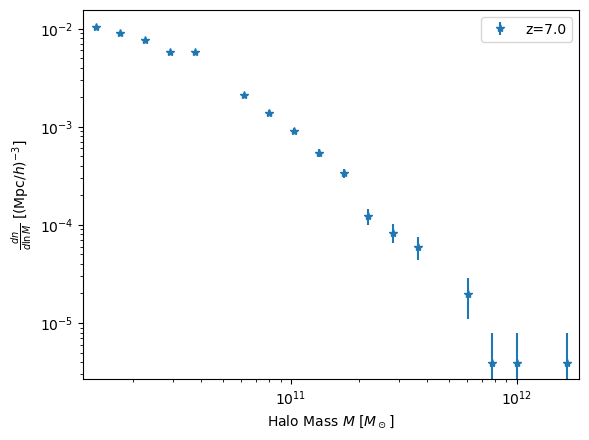

In [6]:
z_target = 7.0
z_index = np.argmin(np.abs(loader.redshifts - z_target))

halo_catalog = loader.load_halo_catalog(z_index)
print(f"Number of halos at z={z_target}: {len(halo_catalog.masses)}")
print(f"Mass range: {halo_catalog.masses.min():.2e} — {halo_catalog.masses.max():.2e} Msol")

# Plot halo mass function from the catalog
fig, ax = plt.subplots()
beorn.plotting.plot_halo_mass_function(ax, halo_catalog, bin_count=20, label=f'z={z_target}')
ax.legend()
plt.show()

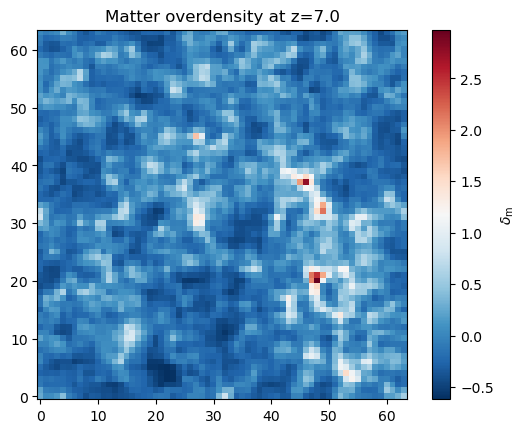

In [7]:
delta_m = loader.load_density_field(z_index)

plt.figure()
plt.imshow(delta_m[:, delta_m.shape[1] // 2, :], origin='lower', cmap='RdBu_r')
plt.colorbar(label=r'$\delta_\mathrm{m}$')
plt.title(f'Matter overdensity at z={z_target}')
plt.show()

## Precompute radiation profiles

In [8]:
solver = beorn.precomputation.RadiationProfileSolver(parameters, loader.redshifts)
profiles = solver.get_or_compute_profiles(cache_handler)

INFO:beorn.precomputation.solver:Loaded radiation profiles from cache.


## Paint grids

In [9]:
output_handler = beorn.io.Handler(OUTPUT_ROOT)

p = beorn.painting.PaintingCoordinator(
    parameters,
    loader=loader,
    cache_handler=cache_handler,
    output_handler=output_handler,
)

multi_z_quantities = p.paint_full(profiles)

INFO:beorn.io.handler:Using persistence directory at output and kwargs None
INFO:beorn.painting.coordinator:Setting up 1 painting processes for MPI.
INFO:beorn.structs.base_struct:Data written to output/TemporalCube_a6290053c76910fa3912c8d928b908eb.h5 (170.02 MB)
INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.
INFO:beorn.painting.coordinator:No halos at z=15.00. Returning empty grids.
INFO:beorn.structs.base_struct:Data written to cache/CoevalCube_a6290053c76910fa3912c8d928b908eb_z_index=0.h5 (8.02 MB)
INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.
INFO:beorn.painting.coordinator:No halos at z=14.50. Returning empty grids.
INFO:beorn.structs.base_struct:Data written to cache/CoevalCube_a6290053c76910fa3912c8d928b908eb_z_index=1.h5 (8.02 MB)
INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.
INFO:beorn.painting.coordinator:No halos 

## Inspect output grids

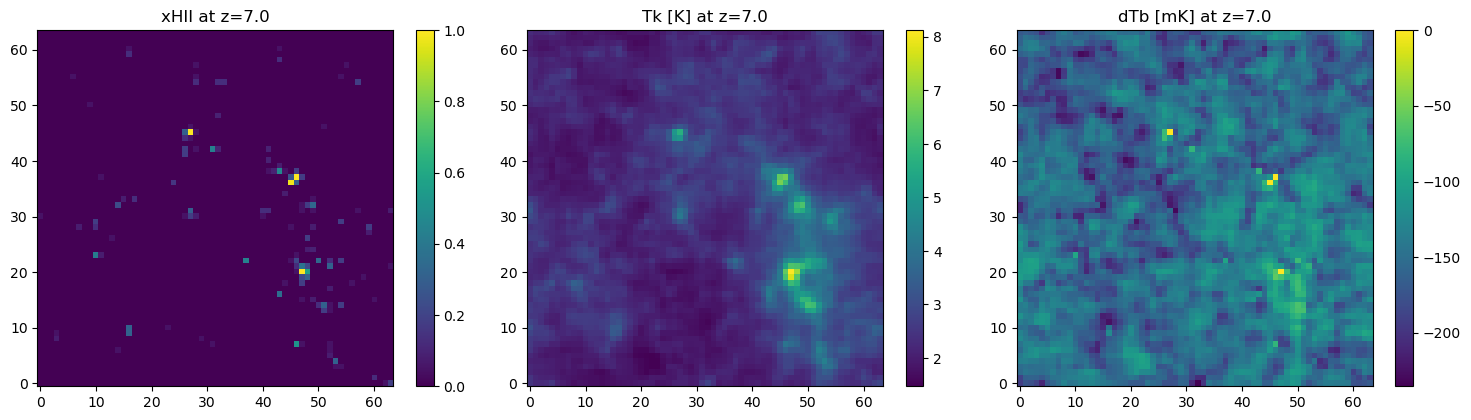

In [10]:
xHII_grid = multi_z_quantities.Grid_xHII[z_index, ...]
dTb_grid  = multi_z_quantities.Grid_dTb[z_index, ...]
Tk_grid   = multi_z_quantities.Grid_Temp[z_index, ...]

mid = xHII_grid.shape[1] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, grid, label in zip(axes,
                            [xHII_grid, Tk_grid, dTb_grid],
                            ['xHII', 'Tk [K]', 'dTb [mK]']):
    im = ax.imshow(grid[:, mid, :], origin='lower', cmap='viridis')
    ax.set_title(f'{label} at z={z_target}')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Global signal and power spectra

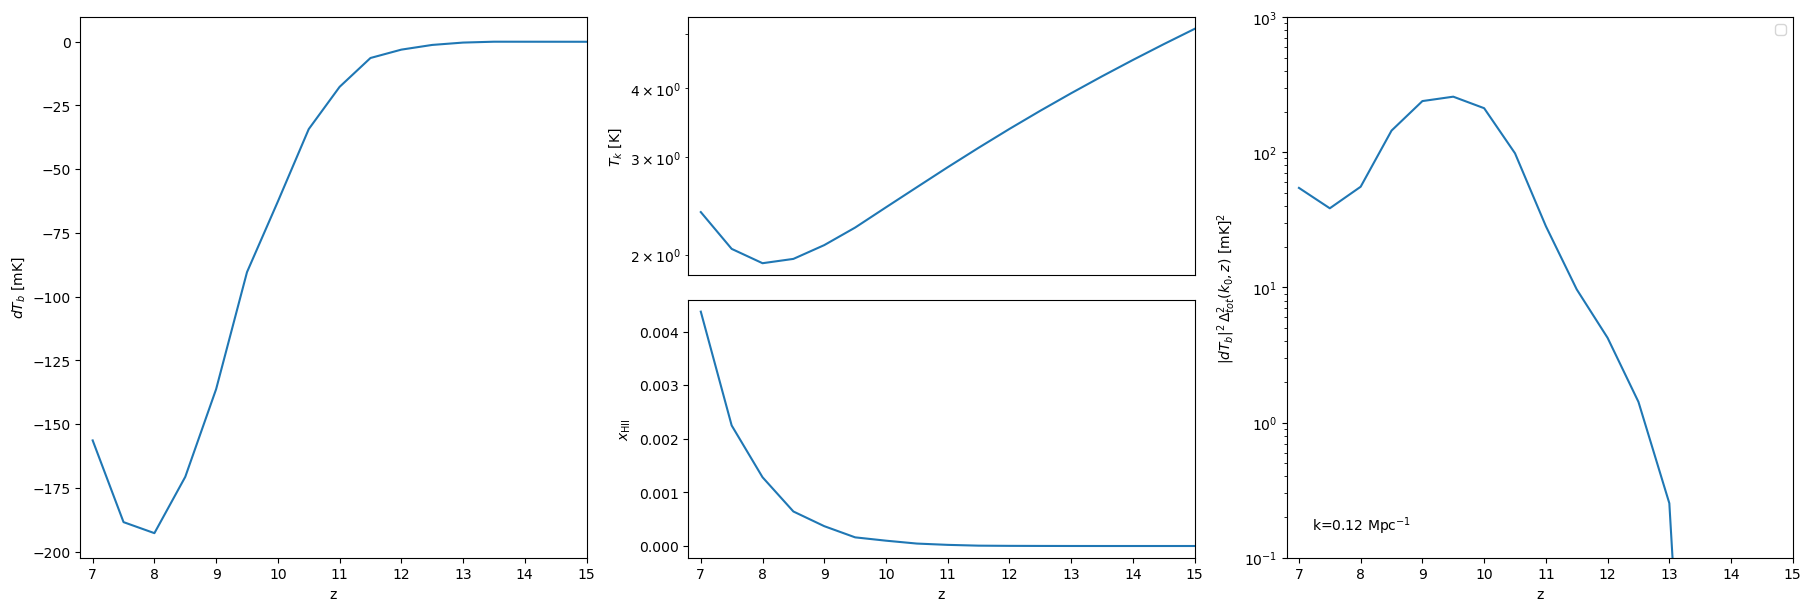

In [11]:
fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities)
beorn.plotting.draw_Temp_signal(ax2, multi_z_quantities)
beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities)
beorn.plotting.draw_dTb_power_spectrum_of_z(ax4, multi_z_quantities, parameters)

ax4.legend(loc='best')
ax2.axes.get_xaxis().set_visible(False)
plt.show()

## Lightcone

Making lightcone between 0.062500 < z < 0.124747


100%|██████████| 165/165 [00:00<00:00, 9177.42it/s]

...done


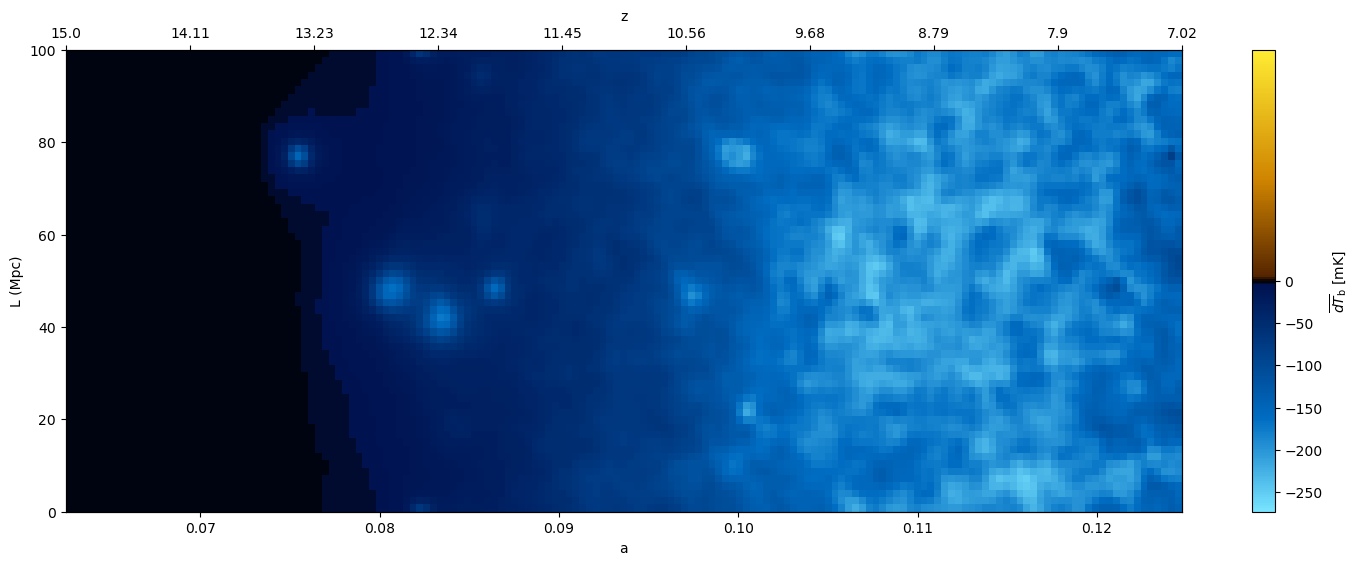

In [12]:
lightcone = beorn.structs.Lightcone.build(
    parameters,
    multi_z_quantities,
    quantity="Grid_dTb",
)

fig, ax = plt.subplots(figsize=(18, 6))
beorn.plotting.plot_lightcone(lightcone, ax, "", slice_number=30)
fig.show()